In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

In [3]:
chopTFs_seq_df =pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/ChopYeastTFsDesign.csv").drop(columns = ["ArrayDNA"])
#chopTFs_seq_df = chopTFs_seq_df[["SpeciesName", "Seq", "Length"]]
chopTFs_seq_df["id"] = chopTFs_seq_df["Name"].str.split("|").str[1].str.split("_").str[0]
chopTFs_seq_df["gene"] = chopTFs_seq_df["Name"].str.split("|").str[0]
chopTFs_seq_df["tile_start"] = chopTFs_seq_df["Name"].str.split("_").str[-1]
chopTFs_seq_df = chopTFs_seq_df[chopTFs_seq_df["gene"] != "nan"]
chopTFs_seq_df

,Unnamed: 0,ADseq,Name,id,gene,tile_start
0,0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,OAF1|YAL051W_1,YAL051W,OAF1,1
1,1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,OAF1|YAL051W_6,YAL051W,OAF1,6
2,2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,OAF1|YAL051W_11,YAL051W,OAF1,11
3,3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,OAF1|YAL051W_16,YAL051W,OAF1,16
4,4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,OAF1|YAL051W_21,YAL051W,OAF1,21
...,...,...,...,...,...,...
18838,47,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD,Gnc4Lib_Kappa_HIGH_0,NaN,Gnc4Lib_Kappa_HIGH_0,0
18839,48,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,Gnc4Lib_Disorder_HIGH_0,NaN,Gnc4Lib_Disorder_HIGH_0,0
18840,49,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK,Gnc4Lib_Disorder_HIGH_0,NaN,Gnc4Lib_Disorder_HIGH_0,0
18841,50,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK,Gnc4Lib_Charge_HIGH_0,NaN,Gnc4Lib_Charge_HIGH_0,0


In [4]:
TF_len = pd.DataFrame(chopTFs_seq_df.groupby("gene")["tile_start"].max()).reset_index().rename(columns = {"tile_start" : "max_tile_start"})
TF_len["len"] = TF_len["max_tile_start"].astype(int) + 40
TF_len

,gene,max_tile_start,len
0,ABF1,96,136
1,ACA1,96,136
2,ACE2,96,136
3,ADR1,996,1036
4,AFT1,96,136
...,...,...,...
512,ZAP1_840,840,880
513,ZAP1_86,86,126
514,ZAP1_91,91,131
515,ZAP1_96,96,136


In [5]:
chopTFs_seq_df = pd.merge(chopTFs_seq_df, TF_len)
chopTFs_seq_df = chopTFs_seq_df.dropna()
chopTFs_seq_df

,Unnamed: 0,ADseq,Name,id,gene,tile_start,max_tile_start,len
0,0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,OAF1|YAL051W_1,YAL051W,OAF1,1,996,1036
1,1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,OAF1|YAL051W_6,YAL051W,OAF1,6,996,1036
2,2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,OAF1|YAL051W_11,YAL051W,OAF1,11,996,1036
3,3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,OAF1|YAL051W_16,YAL051W,OAF1,16,996,1036
4,4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,OAF1|YAL051W_21,YAL051W,OAF1,21,996,1036
...,...,...,...,...,...,...,...,...
17455,18326,NNESKDDIPSKDENSSNDNREISKTDEEGHDSKRRKVSED,FHL1|YPR104C_881,YPR104C,FHL1,881,96,136
17456,18327,DDIPSKDENSSNDNREISKTDEEGHDSKRRKVSEDINEGI,FHL1|YPR104C_886,YPR104C,FHL1,886,96,136
17457,18328,KDENSSNDNREISKTDEEGHDSKRRKVSEDINEGITEVNV,FHL1|YPR104C_891,YPR104C,FHL1,891,96,136
17458,18329,SNDNREISKTDEEGHDSKRRKVSEDINEGITEVNVSLEEK,FHL1|YPR104C_896,YPR104C,FHL1,896,96,136


In [6]:
chopTFs_speeds = pd.read_csv("../../../output/ChopTFs_pipeline/speed/exponential_fit.csv", index_col = 0)[["ADseq", "k"]]
chopTFs_speeds

,ADseq,k
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.269285
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,0.132274
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,0.128593
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,0.096377
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,0.117486
...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,0.093508
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,0.080102
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,0.111316
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,0.084823


In [7]:
def get_all_starts(full_seq, tile):
    starts = []
    start = 0
    while True:
        pos = full_seq.find(tile, start)
        if pos == -1:
            break
        starts.append(pos)
        start = pos + 1
    return starts

import re

def get_gene_stats(gene_chopTFs_seq_df, chopTFs_speeds):
    matching = gene_chopTFs_seq_df.merge(chopTFs_speeds, on='ADseq', how='inner')
    
    if matching.empty:
        return pd.Series({
            'max_speed':       None,
            'mean_speed':      None,
            'median_speed':    None,
            'top3_mean_speed': None,
            'speed_std':       None,
            'tile_count':      0,
            'coverage_fraction': 0.0
        })
    
    covered = set()
    for _, row in matching.iterrows():
        tile_len = len(row['ADseq'])
        pos = int(row['tile_start'])  # cast to int
        covered.update(range(pos, pos + tile_len))
    
    tile_len = len(matching.iloc[0]['ADseq'])
    total_span = int(matching['len'].iloc[0]) + tile_len  # cast here too
    
    speeds = matching['k']
    
    return pd.Series({
        'max_speed':       speeds.max(),
        'mean_speed':      speeds.mean(),
        'median_speed':    speeds.median(),
        'top3_mean_speed': speeds.nlargest(3).mean(),
        'speed_std':       speeds.std(),
        'tile_count':      len(matching),
        'coverage_fraction': len(covered) / total_span
    })

gene_stats_df = (
    chopTFs_seq_df.groupby('gene')
    .apply(lambda g: get_gene_stats(g, chopTFs_speeds))
    .reset_index()
)

In [8]:
gene_stats_df

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364
1,ACA1,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818
2,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000
3,ADR1,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926
4,AFT1,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136
...,...,...,...,...,...,...,...,...
149,YAP7,NaN,NaN,NaN,NaN,NaN,0.0,0.000000
150,YHP1,NaN,NaN,NaN,NaN,NaN,0.0,0.000000
151,YOX1,NaN,NaN,NaN,NaN,NaN,0.0,0.000000
152,YRM1,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682


In [9]:
gene_stats_df_with_max_speeds = gene_stats_df.dropna()
gene_stats_df_with_max_speeds

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364
1,ACA1,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818
2,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000
3,ADR1,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926
4,AFT1,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136
...,...,...,...,...,...,...,...,...
143,WAR1,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955
144,XBP1,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455
145,YAP1,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000
152,YRM1,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682


In [10]:
gene_stats_df_with_max_speeds.to_csv("../../../output/ChopTFs_pipeline/speed/aggreg_per_TF.csv")

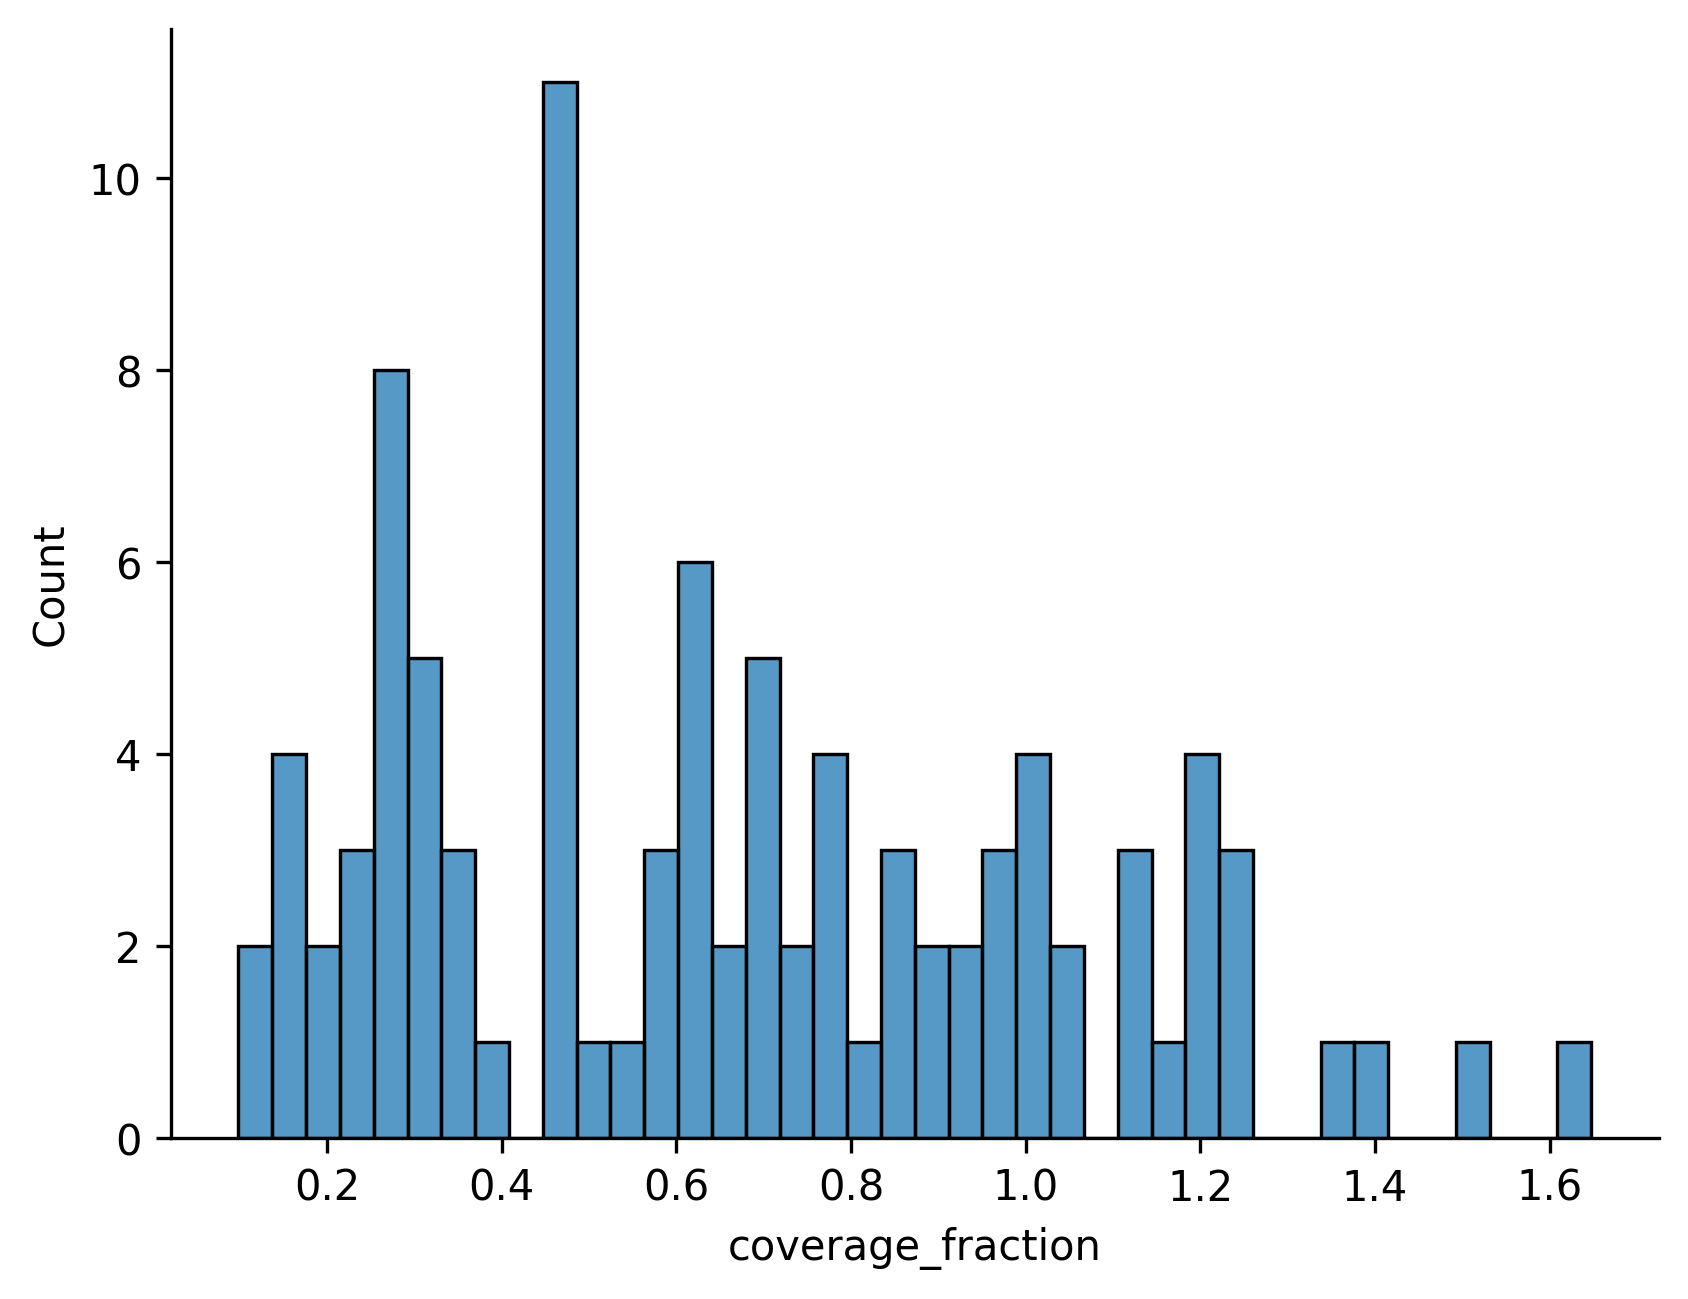

In [11]:
sns.histplot(gene_stats_df_with_max_speeds["coverage_fraction"], bins=40)
sns.despine()

In [12]:
gene_stats_df_with_max_speeds_suffic_cov = gene_stats_df_with_max_speeds[gene_stats_df_with_max_speeds["coverage_fraction"] >= 0]
gene_stats_df_with_max_speeds_suffic_cov

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364
1,ACA1,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818
2,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000
3,ADR1,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926
4,AFT1,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136
...,...,...,...,...,...,...,...,...
143,WAR1,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955
144,XBP1,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455
145,YAP1,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000
152,YRM1,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682


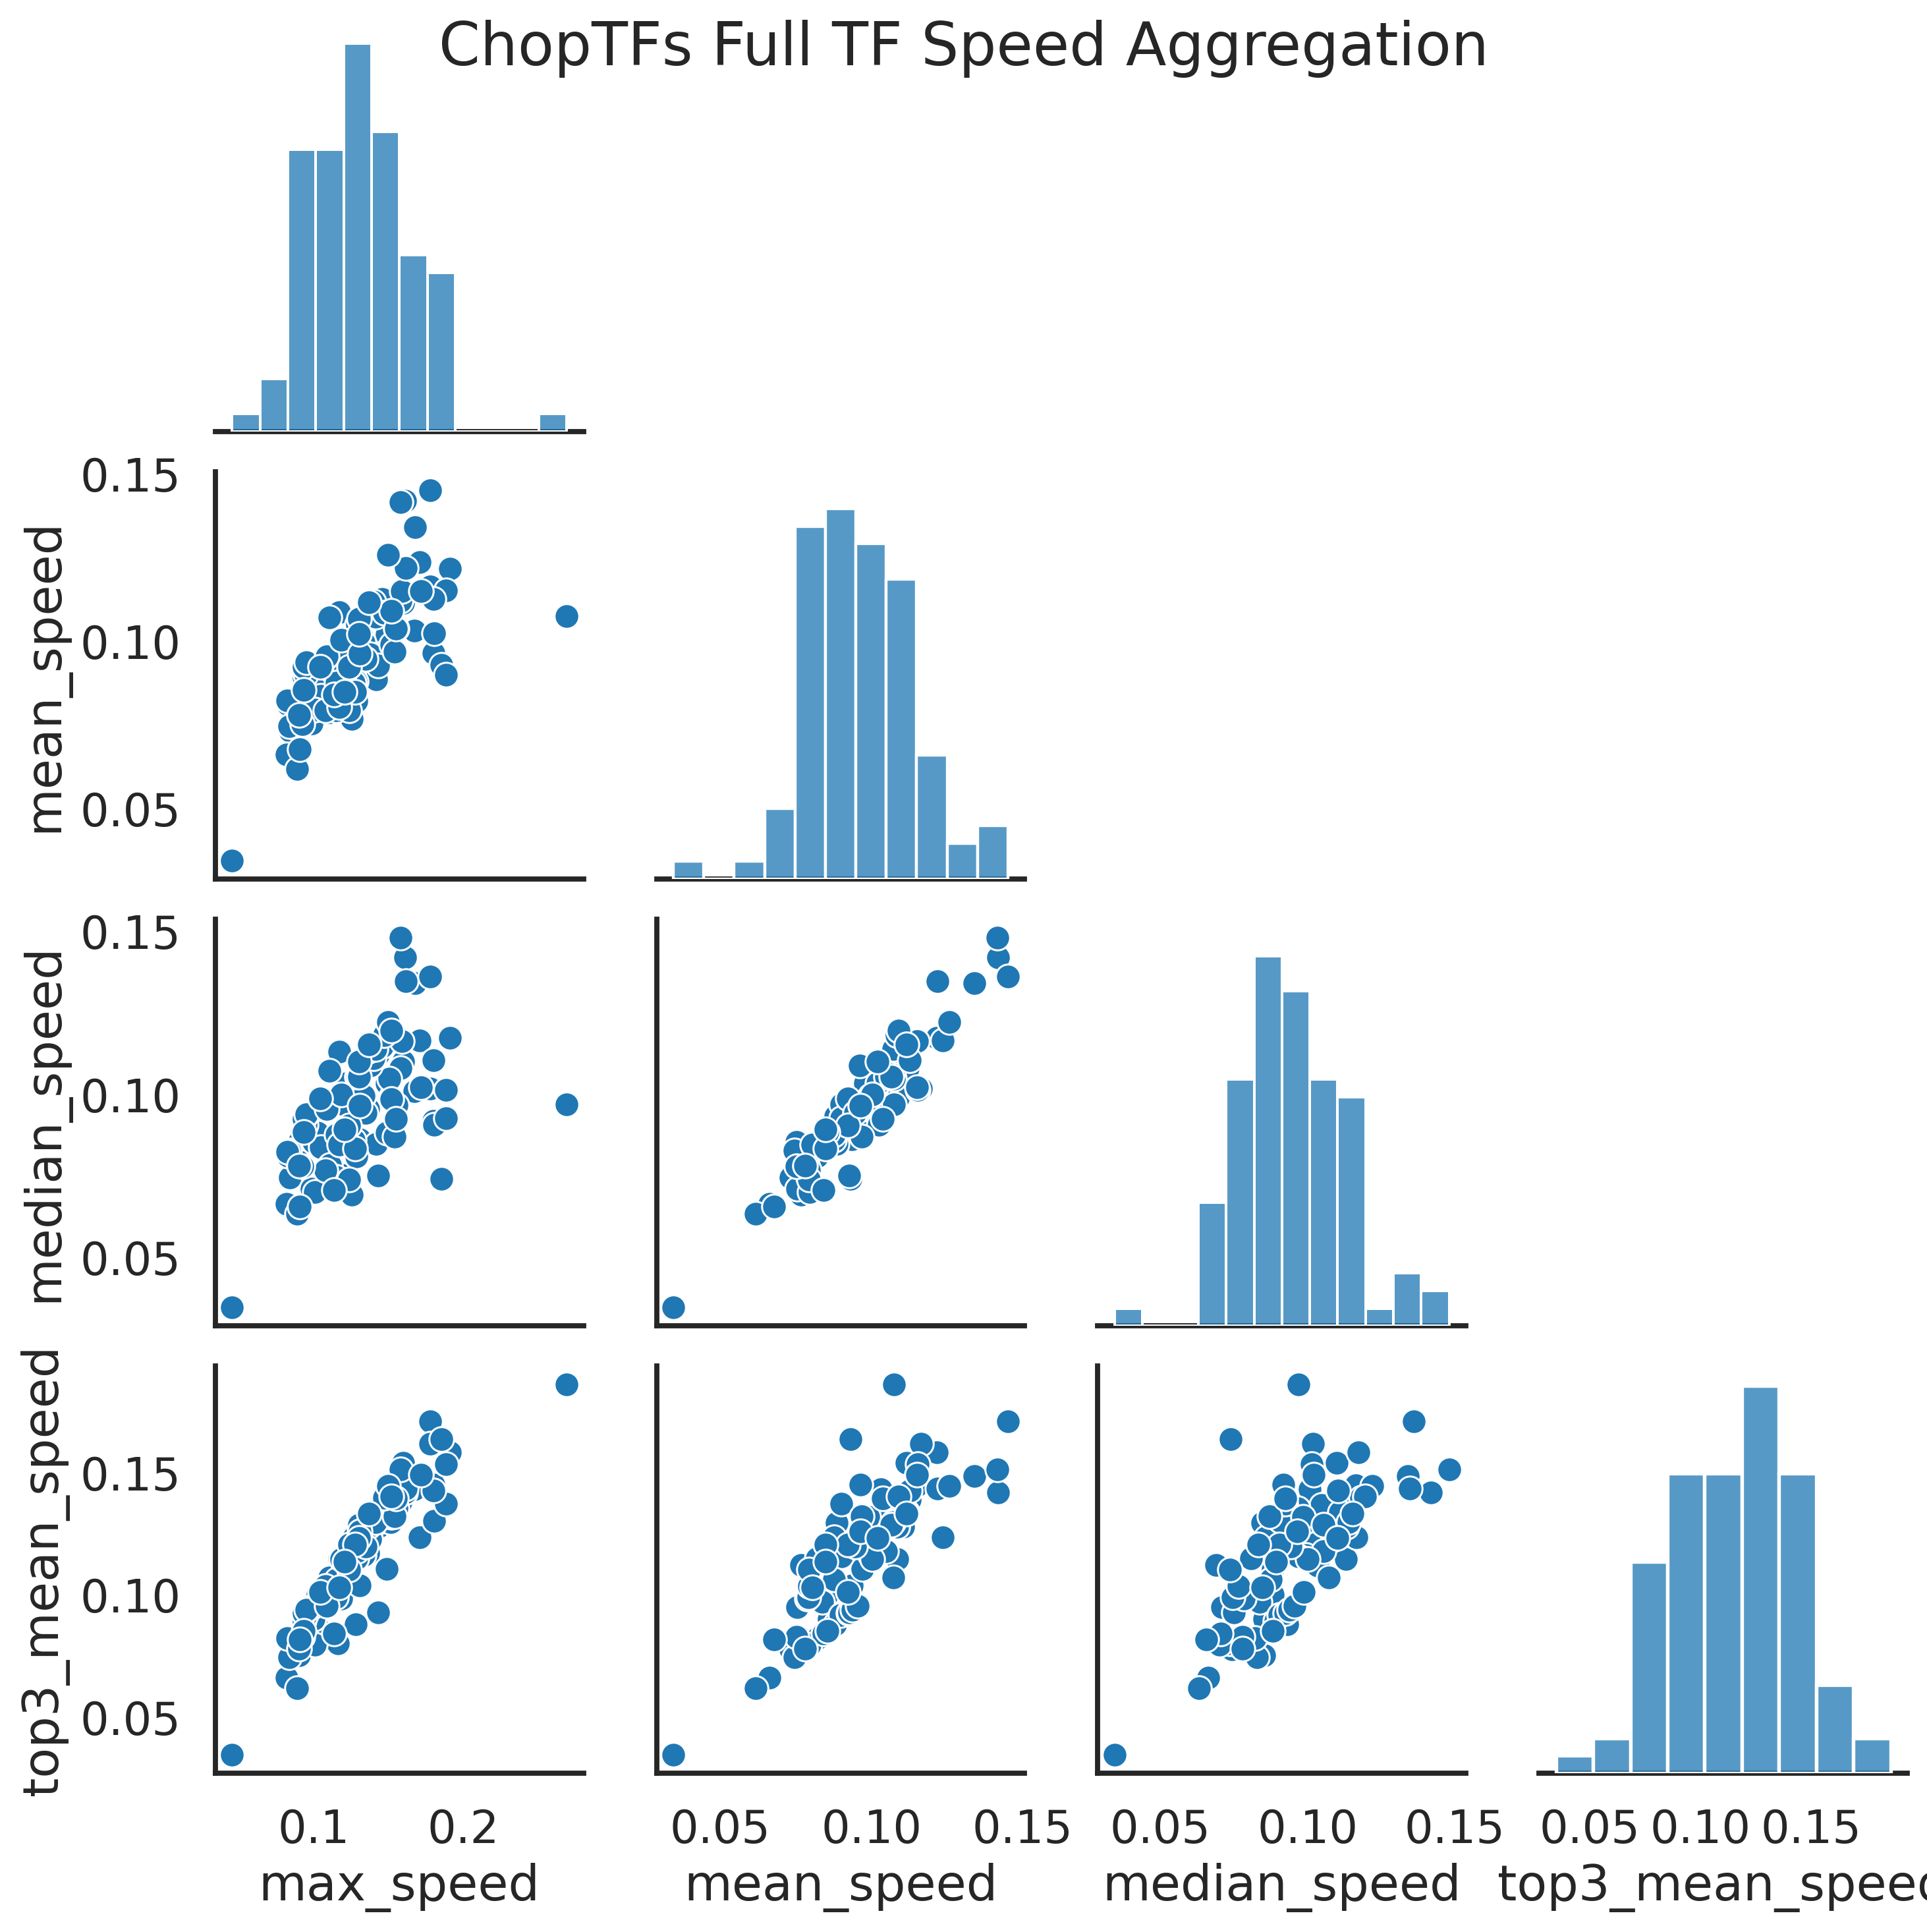

In [13]:
sns.set_context('talk')
sns.set_style('white')
sns.pairplot(gene_stats_df_with_max_speeds_suffic_cov[["max_speed", "mean_speed", "median_speed", "top3_mean_speed"]],
            corner=True)
plt.suptitle("ChopTFs Full TF Speed Aggregation")
plt.show()

In [14]:
gene_stats_df_with_max_speeds_suffic_cov

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364
1,ACA1,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818
2,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000
3,ADR1,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926
4,AFT1,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136
...,...,...,...,...,...,...,...,...
143,WAR1,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955
144,XBP1,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455
145,YAP1,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000
152,YRM1,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682


In [15]:
gene_stats_df = pd.merge(gene_stats_df, chopTFs_seq_df[["id", "gene"]]).drop_duplicates().dropna()
gene_stats_df

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction,id
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364,YKL112W
140,ACA1,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818,YER045C
231,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000,YLR131C
378,ADR1,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926,YDR216W
636,AFT1,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136,YGL071W
...,...,...,...,...,...,...,...,...,...
16379,WAR1,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955,YML076C
16561,XBP1,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455,YIL101C
16684,YAP1,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000,YML007W
17154,YRM1,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682,YOR172W


In [16]:
chopTFs_seq_df

,Unnamed: 0,ADseq,Name,id,gene,tile_start,max_tile_start,len
0,0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,OAF1|YAL051W_1,YAL051W,OAF1,1,996,1036
1,1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,OAF1|YAL051W_6,YAL051W,OAF1,6,996,1036
2,2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,OAF1|YAL051W_11,YAL051W,OAF1,11,996,1036
3,3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,OAF1|YAL051W_16,YAL051W,OAF1,16,996,1036
4,4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,OAF1|YAL051W_21,YAL051W,OAF1,21,996,1036
...,...,...,...,...,...,...,...,...
17455,18326,NNESKDDIPSKDENSSNDNREISKTDEEGHDSKRRKVSED,FHL1|YPR104C_881,YPR104C,FHL1,881,96,136
17456,18327,DDIPSKDENSSNDNREISKTDEEGHDSKRRKVSEDINEGI,FHL1|YPR104C_886,YPR104C,FHL1,886,96,136
17457,18328,KDENSSNDNREISKTDEEGHDSKRRKVSEDINEGITEVNV,FHL1|YPR104C_891,YPR104C,FHL1,891,96,136
17458,18329,SNDNREISKTDEEGHDSKRRKVSEDINEGITEVNVSLEEK,FHL1|YPR104C_896,YPR104C,FHL1,896,96,136


In [17]:
threshold = gene_stats_df['max_speed'].quantile(0.5)

# gene lists
fast_genes = gene_stats_df[gene_stats_df['max_speed'] >= threshold]['id'].tolist()
all_tested = chopTFs_seq_df['id'].drop_duplicates().dropna().tolist()  # background

# save to txt files for upload
with open('../../../output/ChopTFs_pipeline/speed/fast_genes.txt', 'w') as f:
    f.write('\n'.join(fast_genes))

with open('../../../output/ChopTFs_pipeline/speed/background.txt', 'w') as f:
    f.write('\n'.join(all_tested))

In [18]:
len(fast_genes)

48

In [19]:
len(all_tested)

154

In [32]:
# 10 fastest genes for Max 
display(gene_stats_df.sort_values(by = "mean_speed", ascending = False))
print()
for gene in gene_stats_df.sort_values(by = "mean_speed", ascending = False)["gene"].iloc[:10]:
    print(gene)

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction,id
4419,GCN4,0.177846,0.145137,0.136117,0.170935,0.026830,7.0,0.454545,YEL009C
2885,DAL82,0.161224,0.141870,0.141870,0.141870,0.027371,2.0,0.454545,YNL314W
13530,STP2,0.157995,0.141625,0.148060,0.151371,0.020461,4.0,0.681818,YHR006W
231,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000,YLR131C
15367,TEC1,0.149851,0.125839,0.122068,0.144524,0.018957,7.0,0.625000,YBR083W
...,...,...,...,...,...,...,...,...,...
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364,YKL112W
16561,XBP1,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455,YIL101C
3420,ERT1,0.081802,0.066297,0.066297,0.066297,0.021928,2.0,0.454545,YBR239C
7041,MOT2,0.088990,0.061844,0.063314,0.061844,0.027910,3.0,0.284091,YER068W



GCN4
DAL82
STP2
ACE2
TEC1
GZF3
RDR1
GAL4
GLN3
PUT3


In [33]:
# 10 fastest genes for Max 
display(gene_stats_df.sort_values(by = "max_speed", ascending = False))
print()
for gene in gene_stats_df.sort_values(by = "max_speed", ascending = False)["gene"].iloc[:10]:
    print(gene)

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction,id
8468,PIM1,0.269285,0.107450,0.096864,0.185920,0.049062,17.0,0.241636,YBL022C
4009,GAL4,0.191070,0.121727,0.117372,0.158195,0.029226,11.0,1.107955,YPL248C
8862,PUT3,0.188631,0.115298,0.101328,0.153525,0.035033,9.0,0.954545,YKL015W
10700,RPH1,0.188544,0.090058,0.092588,0.137356,0.037583,13.0,0.909091,YER169W
9313,RDS1,0.185457,0.093045,0.074020,0.163615,0.046403,15.0,1.340909,YCR106W
...,...,...,...,...,...,...,...,...,...
6417,MBP1,0.083592,0.074613,0.082777,0.074613,0.014852,3.0,0.539773,YDL056W
2633,CSE4,0.082607,0.081076,0.081076,0.081076,0.002165,2.0,0.255682,YKL049C
8240,PHD1,0.082520,0.082279,0.082279,0.082279,0.000341,2.0,0.284091,YKL043W
3420,ERT1,0.081802,0.066297,0.066297,0.066297,0.021928,2.0,0.454545,YBR239C



PIM1
GAL4
PUT3
RPH1
RDS1
PDR1
CHA4
TYE7
GLN3
GCN4


In [34]:
set(gene_stats_df.sort_values(by = "mean_speed", ascending = False)["gene"].iloc[:10]) & set(gene_stats_df.sort_values(by = "max_speed", ascending = False)["gene"].iloc[:10])

{'GAL4', 'GCN4', 'GLN3', 'PUT3'}